# RKPCN Diagnostics for VSEM Experiment

Single-replicate analysis to understand RKPCN behavior across different $\rho$ values.

**Goal**: Understand why higher $\rho$ values appear to produce worse EP approximations in the VSEM example.

**Key questions**:
1. How quickly does the f-chain mix for different $\rho$?
2. What is the effective sample size (ESS) for u-samples at each $\rho$?
3. Does the log-density trace show the chain stuck in modes?
4. Would more iterations fix the issue for high $\rho$?

In [1]:
from jax import config
config.update('jax_enable_x64', True)

import jax
import jax.numpy as jnp
import jax.random as jr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import NamedTuple

from uncprop.core.samplers import (
    mcmc_loop, init_rkpcn_kernel, _f_update_pcn_proposal, sample_distribution
)
from uncprop.utils.diagnostics import compute_ess
from uncprop.models.vsem.surrogate import VSEMPosteriorSurrogate, LogDensClippedGPSurrogate

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 12

/Users/andrewroberts/Desktop/git-repos/bip-surrogates-paper/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Setup: Reconstruct a replicate

We reconstruct a single replicate from the full experiment run, then re-run RKPCN
with full trace output (not just thinned samples).

In [2]:
# --- Configuration ---
# Point this at your experiment output
EXPERIMENT_NAME = 'vsem_local_test'  # or 'vsem_local_test' for local testing
SURROGATE_TAG = 'clip_gp'  # 'gp' or 'clip_gp'
N_DESIGN = 4
JITTER = 1e-4  # must match the jitter used for this setup
REP_IDX = 0

repo_root = Path('.').resolve().parents[1]
base_dir = repo_root / 'out' / EXPERIMENT_NAME
setup_name = f'{SURROGATE_TAG}_N{N_DESIGN}'
rep_dir = base_dir / setup_name / f'rep{REP_IDX}'

print(f'Rep directory: {rep_dir}')
print(f'Files: {[f.name for f in rep_dir.iterdir()]}')

Rep directory: /Users/andrewroberts/Desktop/git-repos/bip-surrogates-paper/out/vsem_local_test/clip_gp_N4/rep0
Files: ['setup_info.npz', 'grid_densities.npz', 'diagnostics.npz', 'samples.npz', 'coverage.npz', 'rep_key.npy']


In [3]:
# Load the replicate
from experiment import VSEMReplicate
from uncprop.utils.experiment import Experiment

# Read the base key and reconstruct
base_key = jnp.load(base_dir / 'base_key.npy')
base_key = jr.wrap_key_data(base_key)

# Determine the rep key
from uncprop.utils.experiment import Experiment
num_reps = 100
rep_keys = jr.split(base_key, num_reps)
rep_key = rep_keys[REP_IDX]
key_setup, key_run = jr.split(rep_key)

# Reconstruct replicate (this re-fits the surrogate — takes ~10s)
print('Reconstructing replicate...')
surrogate_tag_map = {'gp': 'gp', 'clip_gp': 'clip_gp'}

rep = VSEMReplicate(
    key=key_setup,
    out_dir=rep_dir,
    n_design=N_DESIGN,
    surrogate_tag=SURROGATE_TAG,
    jitter=JITTER,
    write_to_file=False,
)
print('Done.')

Reconstructing replicate...
Initial loss 32.01562989874593
Final loss 29.946322621157083
gp scale: 460.8611049049199
gp lengthscales: [0.41994898 1.45199244]
gp noise std dev: 0.8171641000865547
Done.


In [4]:
# Load saved samples for reference
saved_samp = dict(jnp.load(rep_dir / 'samples.npz'))
saved_diag = dict(jnp.load(rep_dir / 'diagnostics.npz'))

print('Saved sample keys:', list(saved_samp.keys()))
print('\nSaved diagnostics:')
for k, v in saved_diag.items():
    print(f'  {k}: {float(v):.4f}')

Saved sample keys: ['exact', 'mean', 'eup', 'ep', 'rkpcn0', 'rkpcn90', 'rkpcn95', 'rkpcn99']

Saved diagnostics:
  exact_accept_rate: 0.2354
  mean_accept_rate: 0.2387
  eup_accept_rate: 0.2345
  ep_accept_rate: 0.2342
  rkpcn0_accept_rate: 0.3894
  rkpcn90_accept_rate: 0.3081
  rkpcn95_accept_rate: 0.2614
  rkpcn99_accept_rate: 0.1340


## 2. Re-run RKPCN with full trace output

We re-run each $\rho$ value and keep the full MCMC trace (positions, log-densities, accept probs)
instead of just the thinned samples.

In [5]:
def run_rkpcn_full_trace(key, rep, rho, n_total=55_000):
    """
    Run RKPCN and return full (unthinned) trace.
    
    Returns dict with:
        positions: (n_total, d) — u positions
        logdensities: (n_total,) — log-density values
        accept_probs: (n_total,) — MH acceptance probabilities
        is_accepted: (n_total,) — whether each proposal was accepted
    """
    key_ker, key_samp = jr.split(key)
    
    surr = rep.posterior_surrogate
    low, high = surr.support
    upper_bound = lambda u: rep.posterior.prior.log_density(u) + rep.posterior.likelihood.log_density_upper_bound(u)

    if isinstance(surr, LogDensClippedGPSurrogate):
        def log_density(f, u):
            u = jnp.atleast_2d(u)
            upper = upper_bound(u)
            lp = jnp.clip(f, max=upper)
            lp = jnp.where(jnp.all((u >= low) & (u <= high), axis=1), lp, -jnp.inf)
            return lp.squeeze()
    else:
        def log_density(f, u):
            u = jnp.atleast_2d(u)
            lp = f
            lp = jnp.where(jnp.all((u >= low) & (u <= high), axis=1), lp, -jnp.inf)
            return lp.squeeze()

    gp = surr.surrogate
    
    class UpdateInfo(NamedTuple):
        rho: float
    f_update_info = UpdateInfo(rho=rho)

    init_fn, kernel = init_rkpcn_kernel(
        key=key_ker, log_density=log_density, gp=gp,
        f_update_fn=_f_update_pcn_proposal, f_update_info=f_update_info)

    # Use the exact posterior's adapted proposal (matches what experiment does)
    initial_position = rep.posterior.prior.sample(jr.key(0))
    
    # Get adapted proposal from exact posterior MCMC
    key_exact = jr.key(999)
    exact_results = sample_distribution(
        key=key_exact, dist=rep.posterior, initial_position=initial_position,
        n_samples=1000, n_burnin=5000, thin_window=1)
    prop_cov = exact_results['prop_cov']
    
    initial_state = init_fn(key_ker, jnp.squeeze(initial_position), prop_cov)
    
    print(f'  Running RKPCN (rho={rho}, n_total={n_total})...')
    states, infos = mcmc_loop(key=key_samp, kernel=kernel,
                              initial_state=initial_state, num_samples=n_total)
    print(f'  Done. Accept rate: {float(jnp.mean(infos.accept_prob)):.4f}')
    
    return {
        'positions': np.array(states.position),
        'logdensities': np.array(states.logdensity),
        'accept_probs': np.array(infos.accept_prob),
        'is_accepted': np.array(infos.is_accepted),
    }

In [6]:
# Run RKPCN for each rho value
rho_vals = [0.0, 0.9, 0.95, 0.99]
n_total = 55_000  # 50k burnin + 5k post-burnin (matches experiment settings)
n_burnin = 50_000

traces = {}
for rho in rho_vals:
    jax.clear_caches()
    key_rho = jr.key(int(rho * 1000) + 42)
    traces[rho] = run_rkpcn_full_trace(key_rho, rep, rho, n_total=n_total)

print('\nAll runs complete.')

  Running RKPCN (rho=0.0, n_total=55000)...
  Done. Accept rate: 0.3705
  Running RKPCN (rho=0.9, n_total=55000)...
  Done. Accept rate: 0.3119
  Running RKPCN (rho=0.95, n_total=55000)...
  Done. Accept rate: 0.2770
  Running RKPCN (rho=0.99, n_total=55000)...
  Done. Accept rate: 0.1785

All runs complete.


## 3. Log-density trace plots

Shows whether the chain is stuck in modes or exploring smoothly.

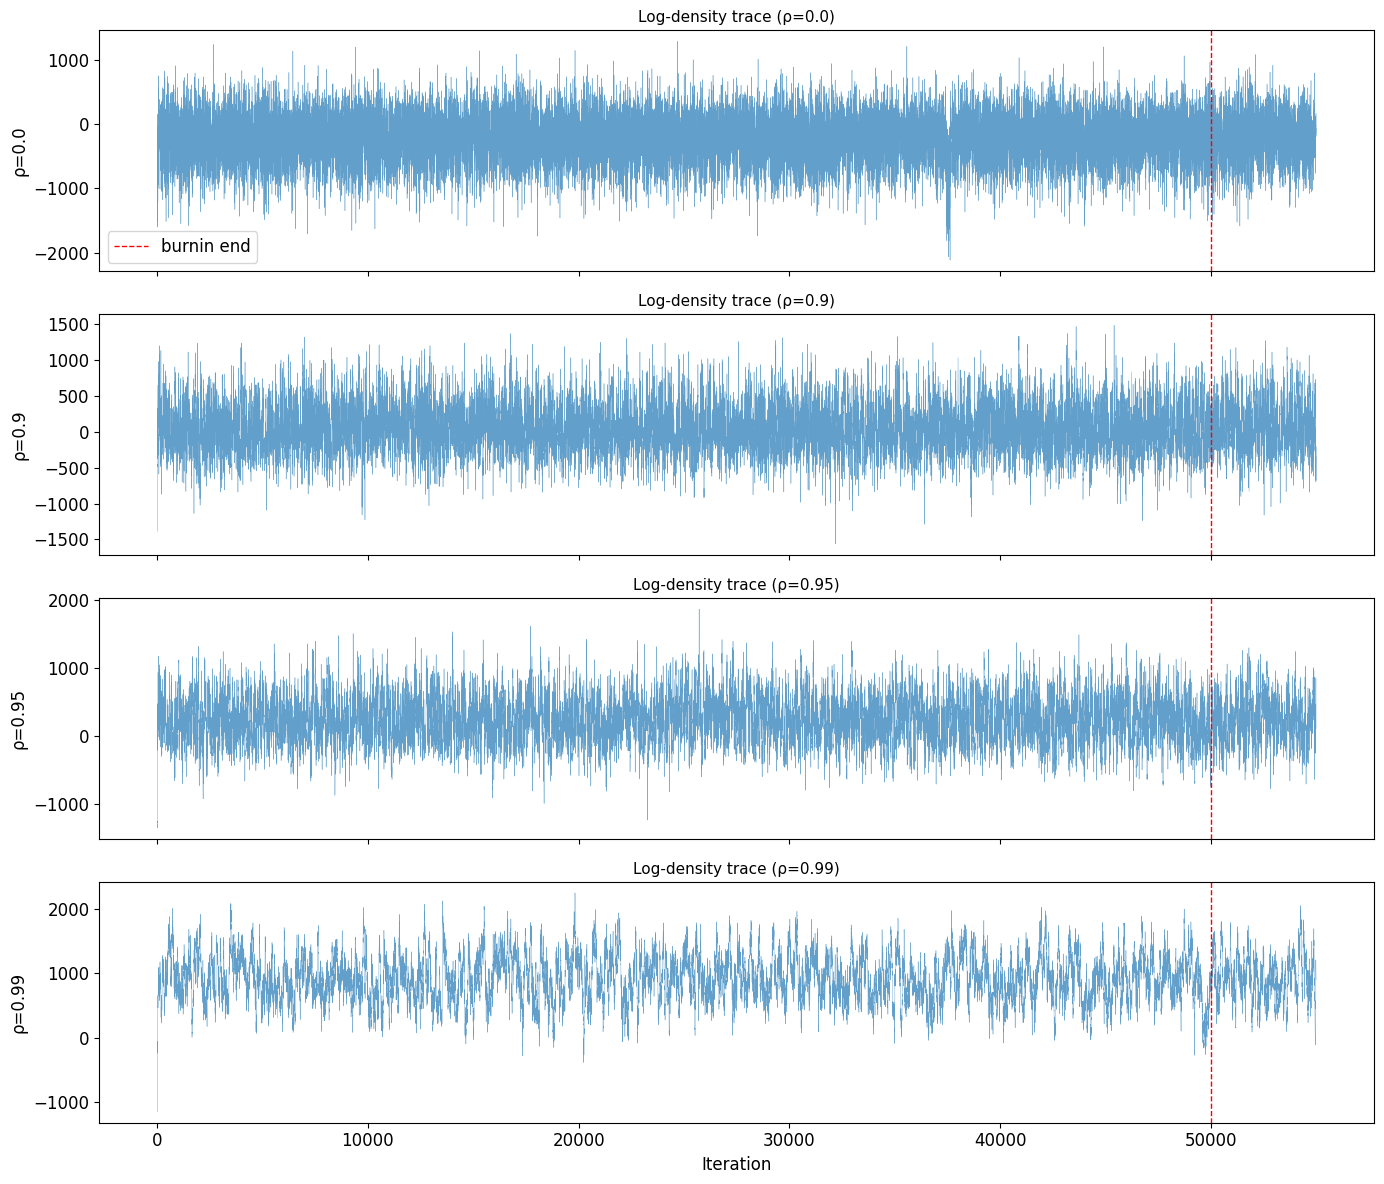

In [7]:
fig, axes = plt.subplots(len(rho_vals), 1, figsize=(14, 3*len(rho_vals)), sharex=True)

for ax, rho in zip(axes, rho_vals):
    ld = traces[rho]['logdensities']
    ax.plot(ld, linewidth=0.3, alpha=0.7)
    ax.axvline(n_burnin, color='red', linestyle='--', linewidth=1, label='burnin end')
    ax.set_ylabel(f'ρ={rho}')
    ax.set_title(f'Log-density trace (ρ={rho})', fontsize=11)
    if rho == rho_vals[0]:
        ax.legend()

axes[-1].set_xlabel('Iteration')
fig.tight_layout()
plt.show()

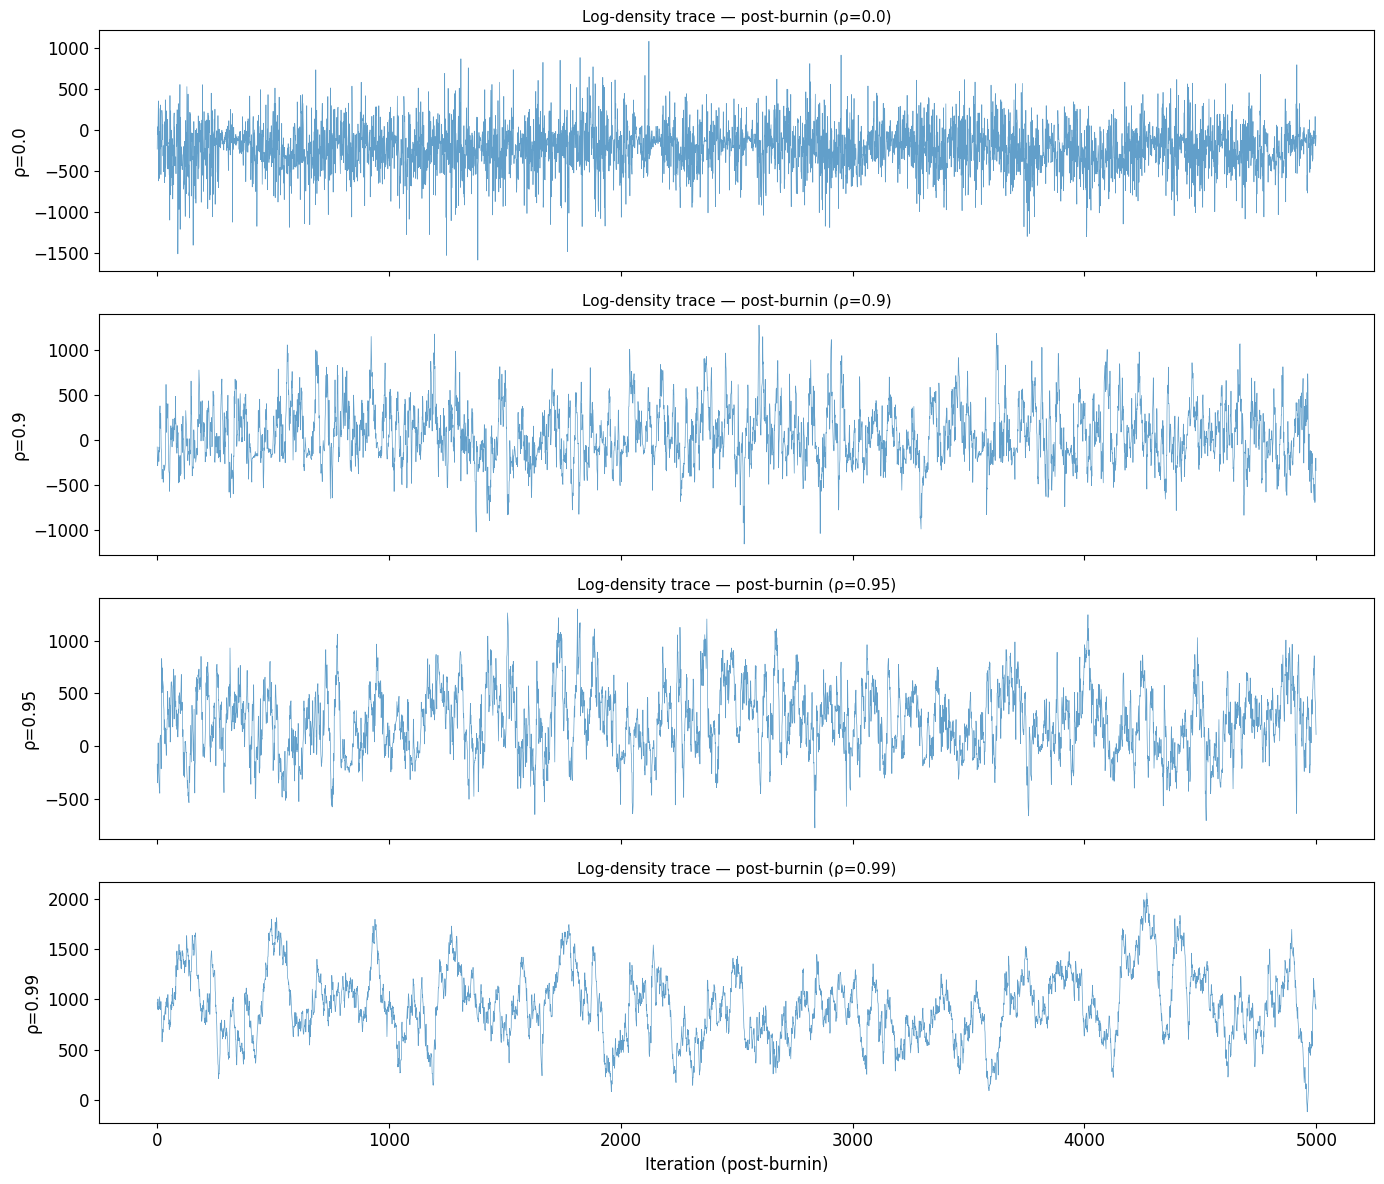

In [8]:
# Zoomed: post-burnin only
fig, axes = plt.subplots(len(rho_vals), 1, figsize=(14, 3*len(rho_vals)), sharex=True)

for ax, rho in zip(axes, rho_vals):
    ld = traces[rho]['logdensities'][n_burnin:]
    ax.plot(ld, linewidth=0.5, alpha=0.7)
    ax.set_ylabel(f'ρ={rho}')
    ax.set_title(f'Log-density trace — post-burnin (ρ={rho})', fontsize=11)

axes[-1].set_xlabel('Iteration (post-burnin)')
fig.tight_layout()
plt.show()

## 4. u-parameter trace plots

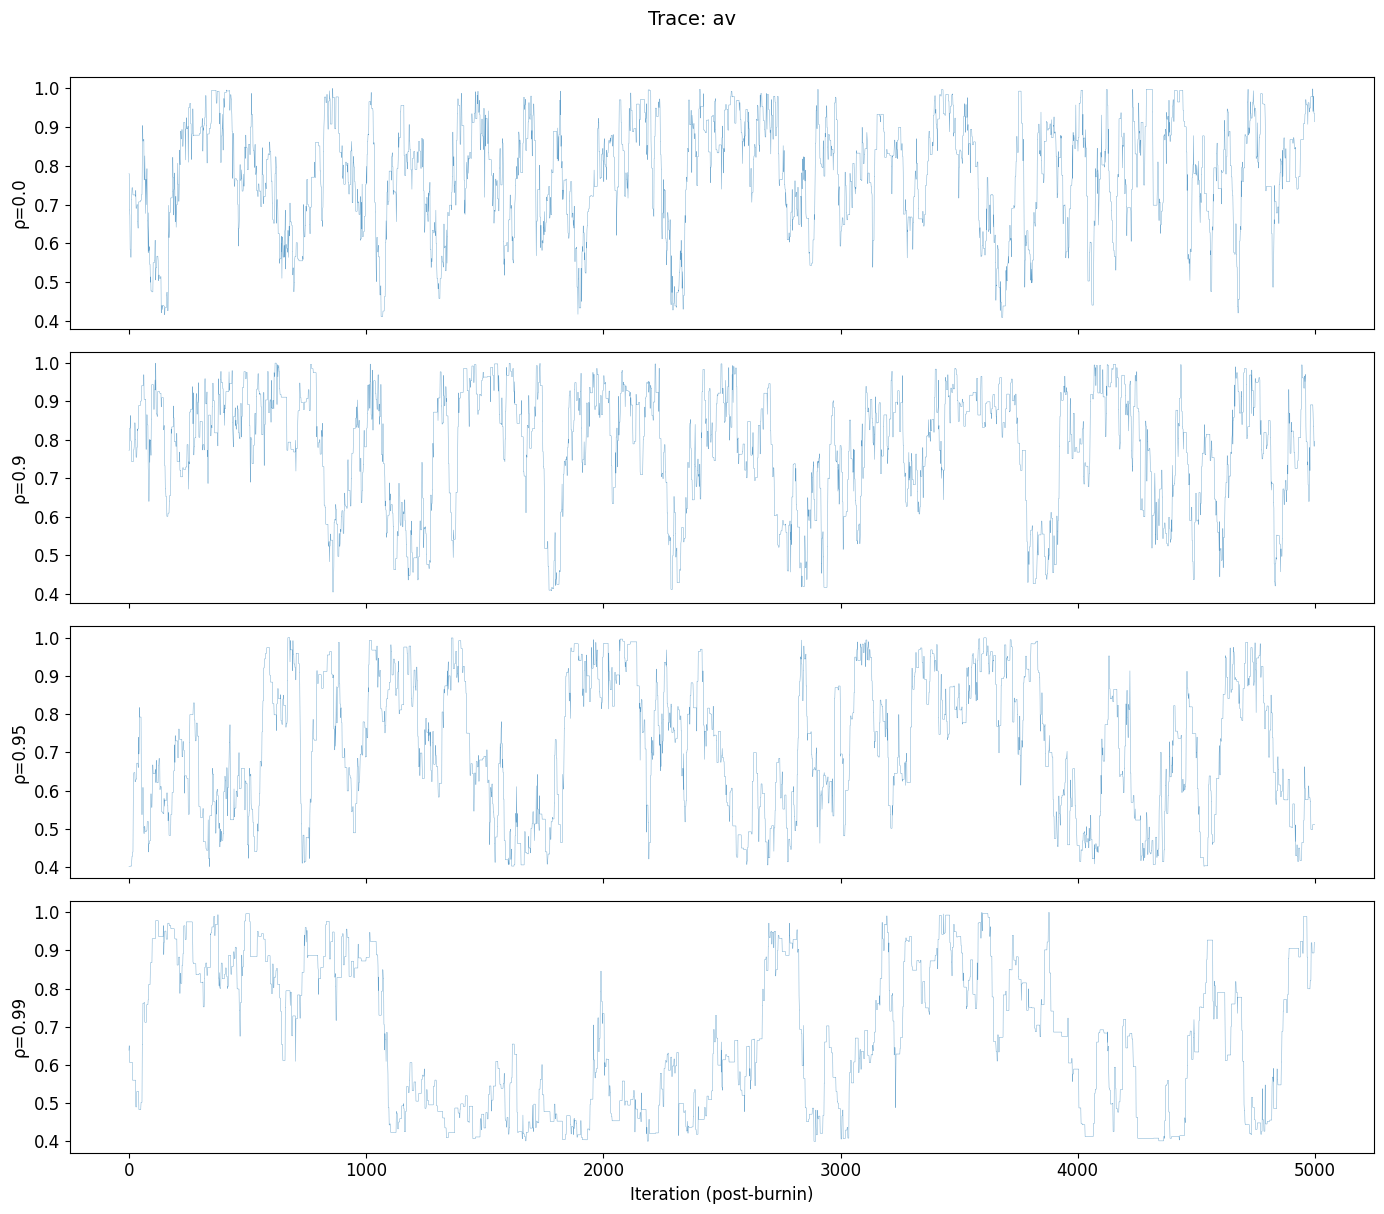

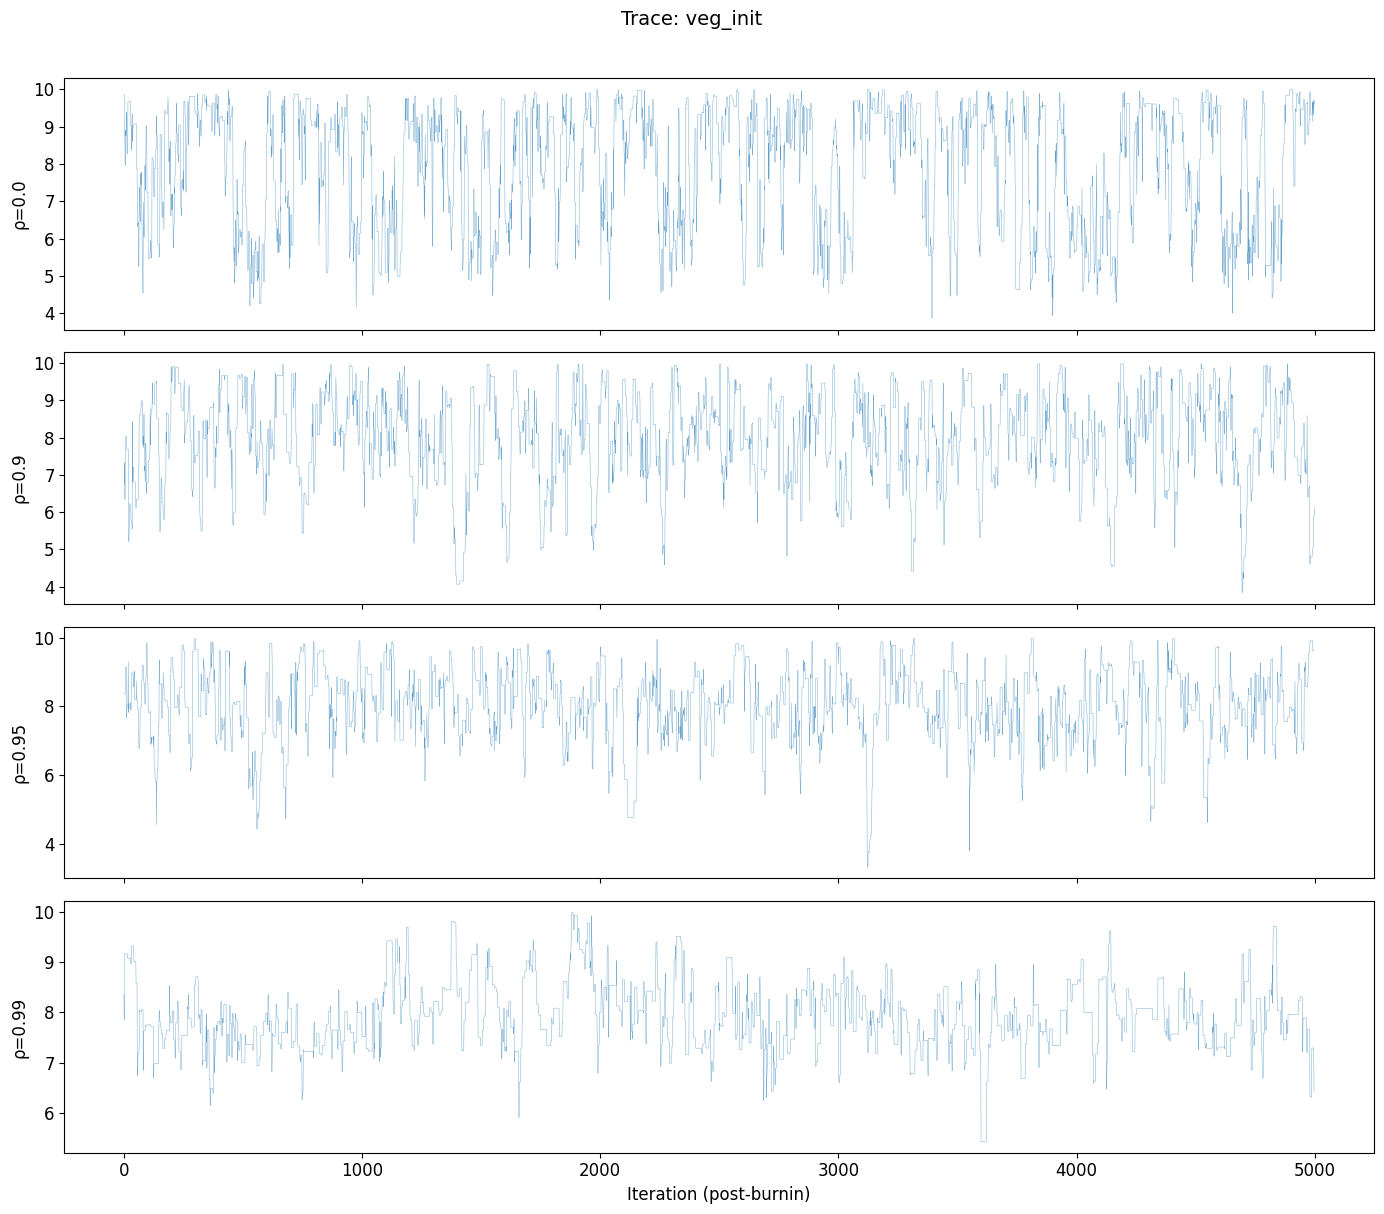

In [9]:
par_names = ['av', 'veg_init']

for d_idx, par_name in enumerate(par_names):
    fig, axes = plt.subplots(len(rho_vals), 1, figsize=(14, 3*len(rho_vals)), sharex=True)
    fig.suptitle(f'Trace: {par_name}', fontsize=14, y=1.01)

    for ax, rho in zip(axes, rho_vals):
        pos = traces[rho]['positions'][n_burnin:, d_idx]
        ax.plot(pos, linewidth=0.3, alpha=0.7)
        ax.set_ylabel(f'ρ={rho}')

    axes[-1].set_xlabel('Iteration (post-burnin)')
    fig.tight_layout()
    plt.show()

## 5. Acceptance rate over time

Rolling acceptance rate to see if it stabilizes.

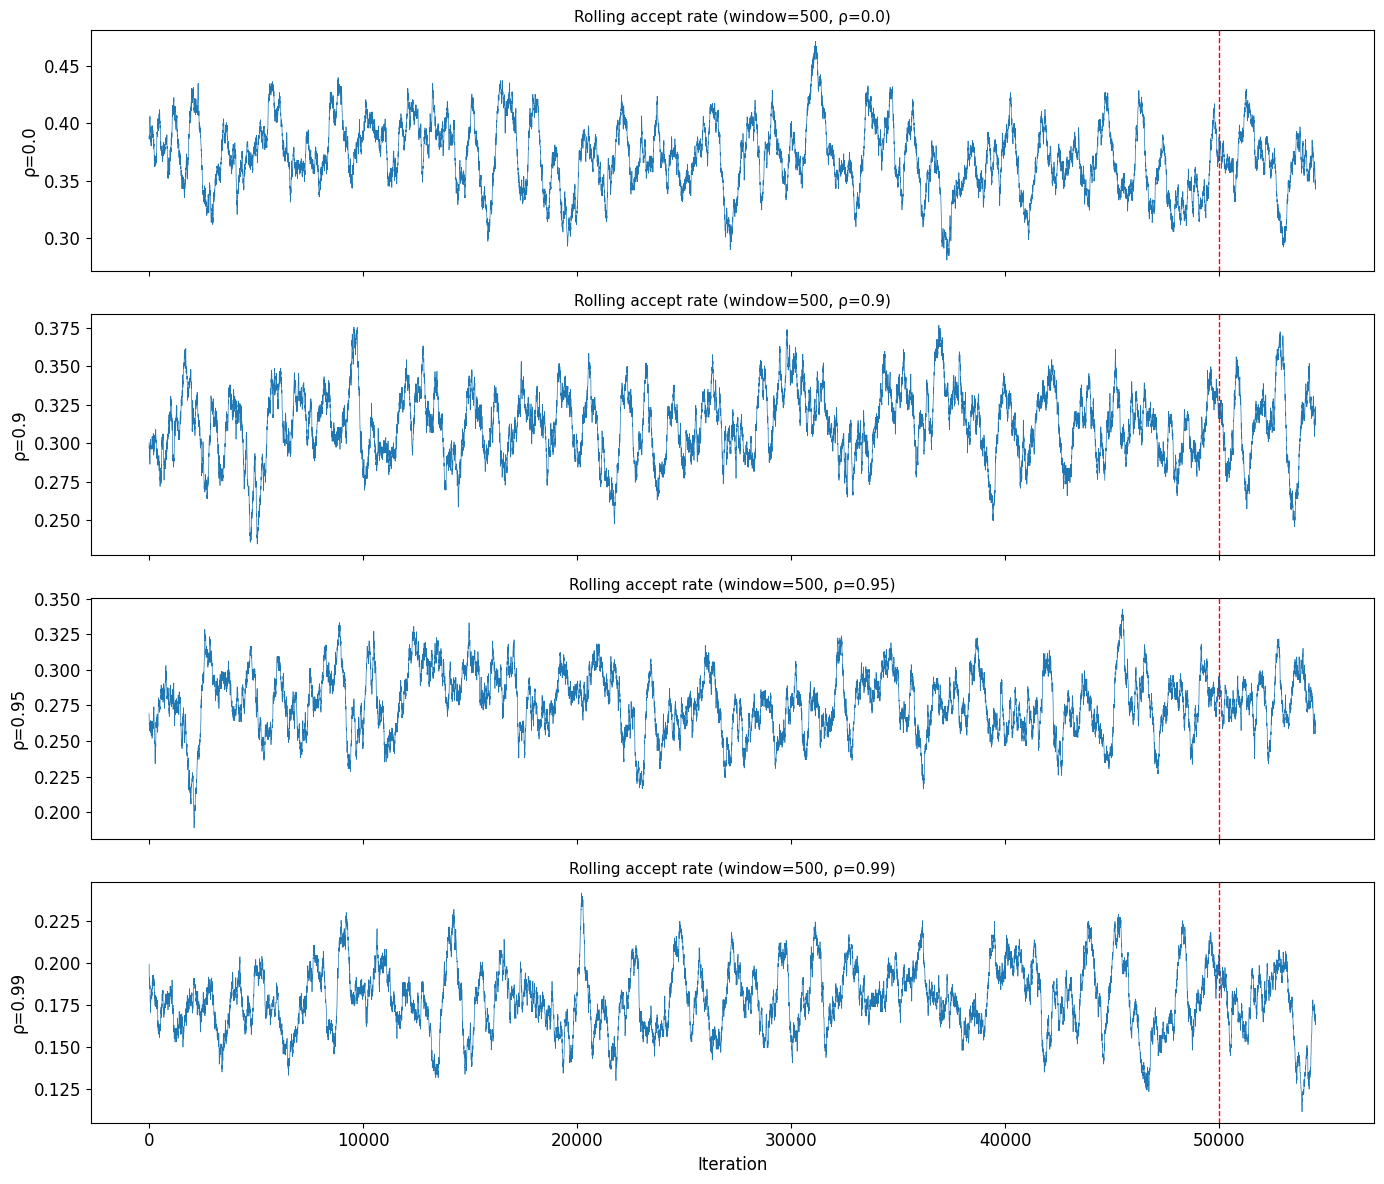

In [10]:
window = 500

fig, axes = plt.subplots(len(rho_vals), 1, figsize=(14, 3*len(rho_vals)), sharex=True)

for ax, rho in zip(axes, rho_vals):
    acc = traces[rho]['accept_probs']
    rolling = np.convolve(acc, np.ones(window)/window, mode='valid')
    ax.plot(rolling, linewidth=0.5)
    ax.axvline(n_burnin, color='red', linestyle='--', linewidth=1)
    ax.set_ylabel(f'ρ={rho}')
    ax.set_title(f'Rolling accept rate (window={window}, ρ={rho})', fontsize=11)

axes[-1].set_xlabel('Iteration')
fig.tight_layout()
plt.show()

## 6. Effective Sample Size (ESS)

In [11]:
print(f'{"rho":>6s} | {"ESS(u1)":>10s} {"ESS(u2)":>10s} | {"min ESS":>10s} | {"accept":>8s} | {"n_post":>8s}')
print('-' * 70)

for rho in rho_vals:
    pos = traces[rho]['positions'][n_burnin:]
    ess = compute_ess(pos)
    acc = np.mean(traces[rho]['accept_probs'][n_burnin:])
    n_post = pos.shape[0]
    print(f'{rho:6.2f} | {ess[0]:10.1f} {ess[1]:10.1f} | {min(ess):10.1f} | {acc:8.4f} | {n_post:8d}')

   rho |    ESS(u1)    ESS(u2) |    min ESS |   accept |   n_post
----------------------------------------------------------------------
  0.00 |      137.7      198.4 |      137.7 |   0.3659 |     5000
  0.90 |      104.6      267.6 |      104.6 |   0.3119 |     5000
  0.95 |       98.5      227.5 |       98.5 |   0.2797 |     5000
  0.99 |       82.3      165.8 |       82.3 |   0.1721 |     5000


## 7. Autocorrelation analysis

Autocorrelation of u-parameters at different lags — shows how quickly the chain decorrelates.

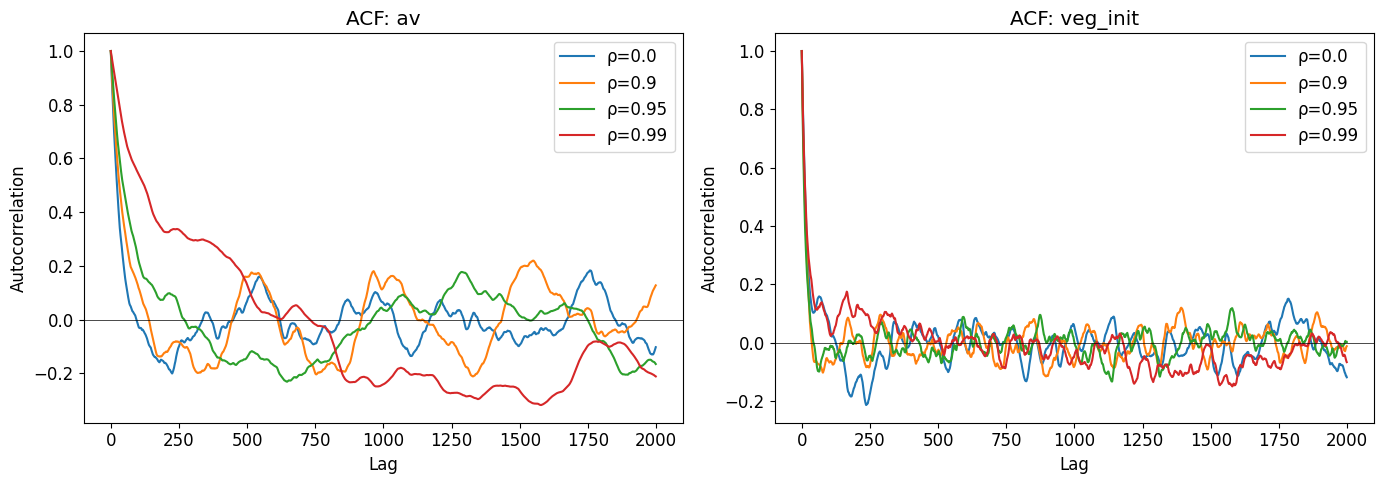

In [12]:
def autocorrelation(x, max_lag=500):
    """Compute autocorrelation for a 1D sequence."""
    x = x - np.mean(x)
    n = len(x)
    var = np.var(x)
    if var < 1e-15:
        return np.zeros(max_lag)
    acf = np.correlate(x, x, mode='full')
    acf = acf[n-1:n-1+max_lag] / (var * n)
    return acf

max_lag = 2000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for d_idx, (ax, par_name) in enumerate(zip(axes, par_names)):
    for rho in rho_vals:
        pos = traces[rho]['positions'][n_burnin:, d_idx]
        acf = autocorrelation(pos, max_lag=max_lag)
        ax.plot(acf, label=f'ρ={rho}', linewidth=1.5)
    
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')
    ax.set_title(f'ACF: {par_name}')
    ax.legend()

fig.tight_layout()
plt.show()

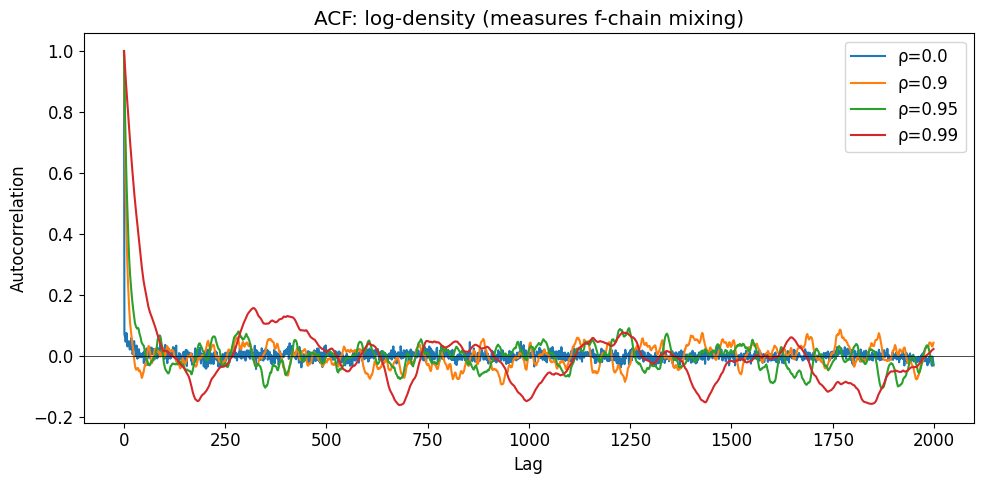

In [13]:
# Also show ACF for log-density (measures f-mixing)
fig, ax = plt.subplots(figsize=(10, 5))

for rho in rho_vals:
    ld = traces[rho]['logdensities'][n_burnin:]
    acf = autocorrelation(ld, max_lag=max_lag)
    ax.plot(acf, label=f'ρ={rho}', linewidth=1.5)

ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')
ax.set_title('ACF: log-density (measures f-chain mixing)')
ax.legend()
fig.tight_layout()
plt.show()

## 8. 2D scatter: RKPCN samples vs EP baseline

Compare the RKPCN samples (post-burnin, thinned) against the grid-based EP samples.

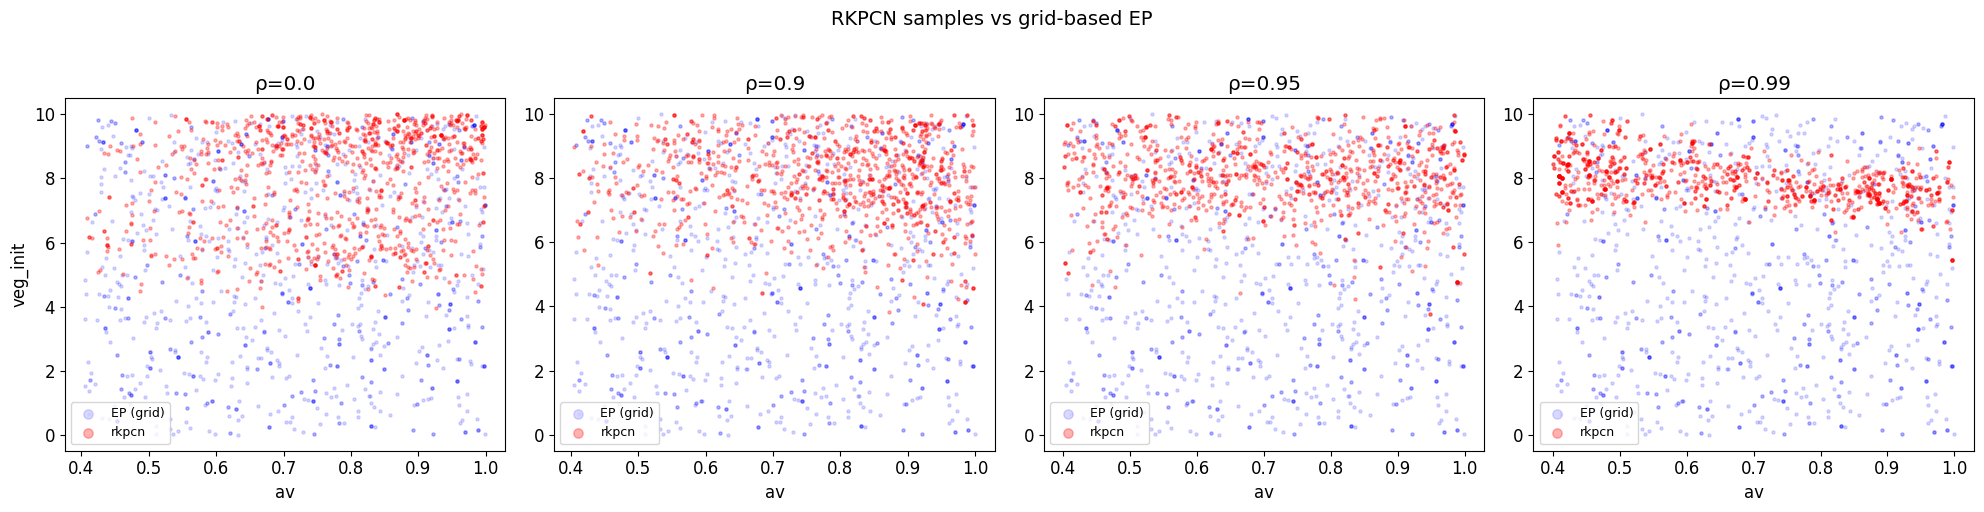

In [14]:
# Grid-based EP samples for reference
ep_samp = saved_samp.get('ep', None)
exact_samp = saved_samp.get('exact', None)

thin = 5

fig, axes = plt.subplots(1, len(rho_vals), figsize=(5*len(rho_vals), 5))

for ax, rho in zip(axes, rho_vals):
    pos = traces[rho]['positions'][n_burnin::thin]
    
    if ep_samp is not None:
        ax.scatter(ep_samp[:, 0], ep_samp[:, 1], alpha=0.15, s=5, c='blue', label='EP (grid)')
    ax.scatter(pos[:, 0], pos[:, 1], alpha=0.3, s=5, c='red', label=f'rkpcn')
    
    ax.set_xlabel(par_names[0])
    if rho == rho_vals[0]:
        ax.set_ylabel(par_names[1])
    ax.set_title(f'ρ={rho}')
    ax.legend(fontsize=9, markerscale=3)

fig.suptitle('RKPCN samples vs grid-based EP', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 9. Effect of more iterations

Re-run ρ=0.99 with 5× more iterations to test whether the issue is simply insufficient chain length.

In [15]:
# Extended run for rho=0.99
n_total_extended = 275_000  # 5x the standard (250k burnin + 25k post-burnin)
n_burnin_extended = 250_000

jax.clear_caches()
key_extended = jr.key(9999)
trace_extended = run_rkpcn_full_trace(key_extended, rep, rho=0.99, n_total=n_total_extended)

# Compare ESS
pos_std = traces[0.99]['positions'][n_burnin:]
pos_ext = trace_extended['positions'][n_burnin_extended:]

ess_std = compute_ess(pos_std)
ess_ext = compute_ess(pos_ext)

print(f'Standard (5k post-burnin):  ESS = {ess_std}, n_samples = {pos_std.shape[0]}')
print(f'Extended (25k post-burnin): ESS = {ess_ext}, n_samples = {pos_ext.shape[0]}')

  Running RKPCN (rho=0.99, n_total=275000)...
  Done. Accept rate: 0.1775
Standard (5k post-burnin):  ESS = [ 82.25079186 165.77261088], n_samples = 5000
Extended (25k post-burnin): ESS = [214.65067112 518.73649459], n_samples = 25000


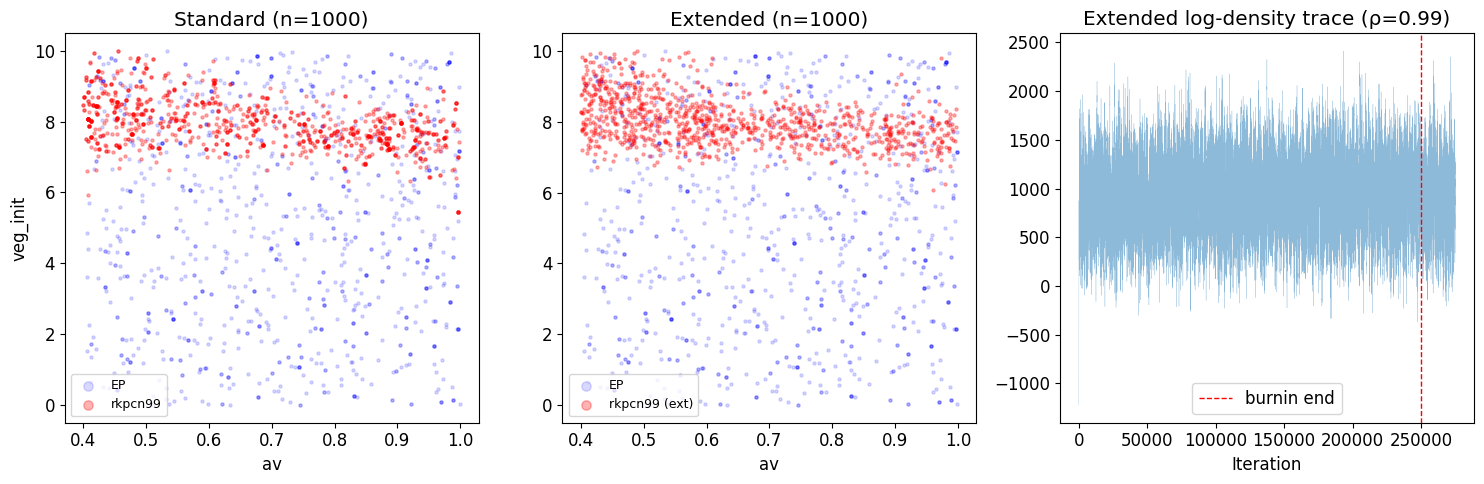

In [16]:
# Compare extended rkpcn99 against EP
thin_ext = 25  # thin more aggressively to get ~1000 samples
pos_ext_thinned = pos_ext[::thin_ext]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Standard rkpcn99
ax = axes[0]
if ep_samp is not None:
    ax.scatter(ep_samp[:, 0], ep_samp[:, 1], alpha=0.15, s=5, c='blue', label='EP')
ax.scatter(pos_std[::thin, 0], pos_std[::thin, 1], alpha=0.3, s=5, c='red', label='rkpcn99')
ax.set_title(f'Standard (n={pos_std[::thin].shape[0]})')
ax.set_xlabel(par_names[0])
ax.set_ylabel(par_names[1])
ax.legend(fontsize=9, markerscale=3)

# Extended rkpcn99
ax = axes[1]
if ep_samp is not None:
    ax.scatter(ep_samp[:, 0], ep_samp[:, 1], alpha=0.15, s=5, c='blue', label='EP')
ax.scatter(pos_ext_thinned[:, 0], pos_ext_thinned[:, 1], alpha=0.3, s=5, c='red', label='rkpcn99 (ext)')
ax.set_title(f'Extended (n={pos_ext_thinned.shape[0]})')
ax.set_xlabel(par_names[0])
ax.legend(fontsize=9, markerscale=3)

# Log-density trace comparison
ax = axes[2]
ld_ext = trace_extended['logdensities']
ax.plot(ld_ext, linewidth=0.2, alpha=0.5)
ax.axvline(n_burnin_extended, color='red', linestyle='--', linewidth=1, label='burnin end')
ax.set_title('Extended log-density trace (ρ=0.99)')
ax.set_xlabel('Iteration')
ax.legend()

fig.tight_layout()
plt.show()

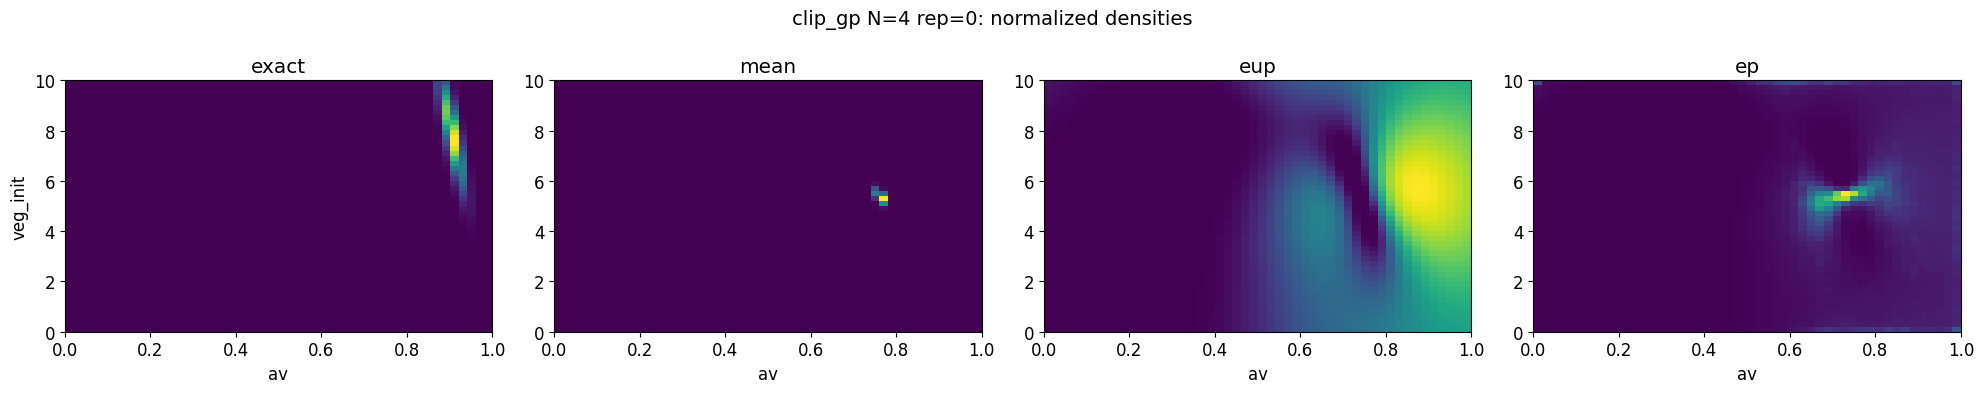


Entropy (higher = flatter):
  exact: 3.999 / 7.824 (51.1% of max)
  mean: 1.770 / 7.824 (22.6% of max)
  eup: 6.961 / 7.824 (89.0% of max)
  ep: 6.742 / 7.824 (86.2% of max)


In [20]:
from uncprop.utils.grid import Grid
import numpy as np

# Grid parameters (same as experiment.py)
grid = Grid(low=np.array([0.0, 0.0]), high=np.array([1.0, 10.0]),
            n_points_per_dim=np.array([50, 50]), dim_names=['av', 'veg_init'])

gd = dict(jnp.load(rep_dir / 'grid_densities.npz'))

from uncprop.utils.grid import normalize_density_over_grid

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, name in zip(axes, ['exact', 'mean', 'eup', 'ep']):
    logp = gd[name]
    # Normalize
    logp_norm, _ = normalize_density_over_grid(logp, cell_area=grid.cell_area)
    probs = np.exp(np.array(logp_norm.squeeze()))
    Z = probs.reshape(50, 50)
    ax.imshow(Z.T, origin='lower', aspect='auto',
              extent=[0, 1, 0, 10])
    ax.set_title(name)
    ax.set_xlabel('av')
    if name == 'exact':
        ax.set_ylabel('veg_init')

fig.suptitle(f'{SURROGATE_TAG} N={N_DESIGN} rep={REP_IDX}: normalized densities', fontsize=14)
fig.tight_layout()
plt.show()

# Print entropy as a flatness metric (uniform = max entropy)
print('\nEntropy (higher = flatter):')
max_entropy = np.log(2500)  # uniform over 2500 grid points
for name in ['exact', 'mean', 'eup', 'ep']:
    logp_norm, _ = normalize_density_over_grid(gd[name], cell_area=grid.cell_area)
    p = np.exp(np.array(logp_norm.squeeze()))
    p = p[p > 0]
    entropy = -np.sum(p * np.log(p))
    print(f'  {name}: {entropy:.3f} / {max_entropy:.3f} ({entropy/max_entropy*100:.1f}% of max)')


## 10. W2 comparison

Compute W2 distances to grid-based EP for each ρ, including the extended ρ=0.99 run.

In [ ]:
from uncprop.utils.wasserstein import wasserstein2_sinkhorn

if ep_samp is not None:
    print(f'{"method":>20s} | {"W2":>8s} | {"n_samp":>8s} | {"min ESS":>8s}')
    print('-' * 55)
    
    for rho in rho_vals:
        pos = traces[rho]['positions'][n_burnin::thin]
        ess = compute_ess(pos)
        w2 = wasserstein2_sinkhorn(jnp.array(ep_samp), jnp.array(pos),
                                   threshold=1e-6, max_iterations=5000)
        label = 'cut' if rho == 0.0 else f'rkpcn{int(rho*100)}'
        print(f'{label:>20s} | {float(w2):8.4f} | {pos.shape[0]:8d} | {min(ess):8.1f}')
    
    # Extended rkpcn99
    ess_ext = compute_ess(pos_ext_thinned)
    w2_ext = wasserstein2_sinkhorn(jnp.array(ep_samp), jnp.array(pos_ext_thinned),
                                   threshold=1e-6, max_iterations=5000)
    print(f'{"rkpcn99 (extended)":>20s} | {float(w2_ext):8.4f} | {pos_ext_thinned.shape[0]:8d} | {min(ess_ext):8.1f}')
    
    # EUP for reference
    eup_samp = saved_samp.get('eup', None)
    if eup_samp is not None:
        w2_eup = wasserstein2_sinkhorn(jnp.array(ep_samp), jnp.array(eup_samp),
                                       threshold=1e-6, max_iterations=5000)
        print(f'{"eup":>20s} | {float(w2_eup):8.4f} | {eup_samp.shape[0]:8d} | {"N/A":>8s}')
else:
    print('No EP samples available for W2 comparison.')

## 11. Summary

Key takeaways from this replicate:

1. **Log-density traces**: Does ρ=0.99 show the chain stuck at a fixed level (slow f-mixing) while ρ=0 shows rapid fluctuations (fast f-mixing)?

2. **ESS**: How does ESS scale with ρ? Expect ESS to decrease with ρ.

3. **ACF of log-density**: The decorrelation time in log-density directly measures f-mixing speed. Expect ~1/(1-ρ²) scaling.

4. **Extended run**: Does 5× more iterations for ρ=0.99 close the gap with lower-ρ runs? If yes, the fix is simply scaling iterations. If not, there may be deeper issues.

5. **2D scatter**: Does ρ=0.99 cover the same region as EP, just with fewer effective samples? Or is it concentrated in a subregion?

---

# Part 2: EP Baseline Diagnostics

The EP approximation is computed on a grid via Monte Carlo:

$$\hat{\pi}_{EP}(u_j) = \frac{1}{S} \sum_{s=1}^{S} \frac{\pi(u_j; f^{(s)})}{Z(f^{(s)})}$$

where $f^{(s)}$ are GP trajectory samples and $Z(f^{(s)}) = \sum_j \pi(u_j; f^{(s)}) \cdot \Delta A$.

**Concern**: The grid-based EP, the MCMC-based EP, and direct grid sampling from EP all give different-looking distributions. We need to understand why and whether the grid-based EP computation is trustworthy.

Key questions:
1. How sensitive is the EP density to individual trajectory samples?
2. Do the normalized per-trajectory densities look reasonable?
3. Is the Monte Carlo average converged at $S = 10{,}000$?
4. Do grid-sampled EP points match the EP heatmap?

## 12. Inspect individual GP trajectory posteriors

Sample several GP trajectories and look at the normalized density each produces.
This reveals whether individual trajectories produce reasonable posteriors or if
some are degenerate.

In [ ]:
from uncprop.utils.grid import normalize_density_over_grid
from uncprop.models.vsem.surrogate import LogDensClippedGPSurrogate

surr = rep.posterior_surrogate
n_mc = 20  # small number to inspect individually

# Sample GP trajectories at grid points
key_traj = jr.key(123)
logpi_samples = surr.posterior_surrogate.sample_surrogate_pred(
    key_traj, input=grid.flat_grid, n=n_mc)  # (n_mc, n_grid)
print(f'logpi_samples shape: {logpi_samples.shape}')
print(f'logpi range: [{float(logpi_samples.min()):.1f}, {float(logpi_samples.max()):.1f}]')

# Normalize each trajectory
logp_norm, logZ = normalize_density_over_grid(
    logpi_samples, cell_area=grid.cell_area, return_log=True)
print(f'\nlog Z per trajectory: {np.array(logZ)}')

# Plot a selection of individual trajectory posteriors
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
for i, ax in enumerate(axes.flat):
    if i >= n_mc:
        ax.set_visible(False)
        continue
    p = np.exp(np.array(logp_norm[i]))
    Z = p.reshape(50, 50)
    ax.imshow(Z.T, origin='lower', aspect='auto', extent=[0, 1, 0, 10])
    ax.set_title(f'traj {i} (logZ={float(logZ[i]):.1f})')
    ax.set_xlabel('av')
    if i % 5 == 0:
        ax.set_ylabel('veg_init')

fig.suptitle('Normalized per-trajectory posteriors', fontsize=14)
fig.tight_layout()
plt.show()

In [ ]:
# Entropy of each trajectory posterior (lower = more concentrated)
max_entropy = np.log(grid.n_points)
entropies = []
for i in range(n_mc):
    p = np.exp(np.array(logp_norm[i]))
    p = p[p > 0]
    h = -np.sum(p * np.log(p))
    entropies.append(h)

entropies = np.array(entropies)
print(f'Per-trajectory entropy (max={max_entropy:.2f}):')
print(f'  mean: {entropies.mean():.2f}')
print(f'  std:  {entropies.std():.2f}')
print(f'  min:  {entropies.min():.2f} (traj {entropies.argmin()})')
print(f'  max:  {entropies.max():.2f} (traj {entropies.argmax()})')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(n_mc), entropies)
ax.axhline(max_entropy, color='red', linestyle='--', label='uniform')
ax.set_xlabel('Trajectory index')
ax.set_ylabel('Entropy')
ax.set_title('Entropy of normalized per-trajectory posteriors')
ax.legend()
plt.show()

## 13. Monte Carlo convergence of EP

Compute the EP estimate at increasing sample sizes to see if/when it converges.

In [ ]:
from jax.scipy.special import logsumexp as jax_logsumexp

# Sample a large batch of trajectories
n_mc_large = 10_000
key_mc = jr.key(456)
logpi_all = surr.posterior_surrogate.sample_surrogate_pred(
    key_mc, input=grid.flat_grid, n=n_mc_large)  # (n_mc_large, n_grid)

logp_norm_all, logZ_all = normalize_density_over_grid(
    logpi_all, cell_area=grid.cell_area, return_log=True)
print(f'Sampled {n_mc_large} trajectories')
print(f'logZ range: [{float(logZ_all.min()):.1f}, {float(logZ_all.max()):.1f}]')

# Compute running EP estimate at different sample sizes
sample_sizes = [10, 50, 100, 500, 1000, 2000, 5000, 10000]
ep_estimates = {}
for S in sample_sizes:
    # EP = (1/S) * sum exp(logp_norm[s])  =>  log EP = logsumexp(logp_norm[:S], axis=0) - log(S)
    log_ep_S = jax_logsumexp(logp_norm_all[:S], axis=0) - jnp.log(S)
    ep_estimates[S] = np.array(log_ep_S)

# Plot convergence: EP density at the grid peak
peak_idx = int(jnp.argmax(jnp.array(ep_estimates[10000])))
print(f'Peak grid index: {peak_idx}, location: {np.array(grid.flat_grid[peak_idx])}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: EP at peak vs sample size
ax = axes[0]
peak_vals = [ep_estimates[S][peak_idx] for S in sample_sizes]
ax.semilogx(sample_sizes, peak_vals, 'o-')
ax.set_xlabel('Number of MC trajectories (S)')
ax.set_ylabel('log EP at peak')
ax.set_title('EP convergence at peak location')

# Right: L2 change between successive estimates
ax = axes[1]
l2_diffs = []
for i in range(1, len(sample_sizes)):
    S_prev, S_curr = sample_sizes[i-1], sample_sizes[i]
    diff = np.sqrt(np.mean((ep_estimates[S_curr] - ep_estimates[S_prev])**2))
    l2_diffs.append(diff)
ax.loglog(sample_sizes[1:], l2_diffs, 'o-')
ax.set_xlabel('Number of MC trajectories (S)')
ax.set_ylabel('L2 change from previous estimate')
ax.set_title('MC convergence rate')

fig.tight_layout()
plt.show()

## 14. Grid-sampled vs MCMC EP comparison

Direct comparison of: (a) the grid-based EP density, (b) samples drawn from the grid, (c) MCMC EP samples.
This diagnoses whether the scatter-vs-heatmap discrepancy is a sampling issue or a density issue.

In [ ]:
from uncprop.utils.grid import DensityComparisonGrid
from scipy.stats import gaussian_kde

# 1. Grid-based EP density (from disk)
gd = dict(jnp.load(rep_dir / 'grid_densities.npz'))
ep_logdens = gd['ep']
ep_norm, _ = normalize_density_over_grid(ep_logdens, cell_area=grid.cell_area)
ep_probs = np.exp(np.array(ep_norm.squeeze()))

# 2. Grid-sampled EP (draw from the discrete distribution)
key_grid_samp = jr.key(789)
n_draw = 2000
idx = jr.choice(key_grid_samp, a=grid.n_points, shape=(n_draw,),
                p=jnp.array(ep_probs), replace=True)
ep_grid_samp = np.array(grid.flat_grid[idx])

# 3. MCMC EP samples (from disk)
ep_mcmc_samp = np.array(saved_samp['ep'])

# 4. Also compute KDE from MCMC samples evaluated on grid
kde_mcmc = gaussian_kde(ep_mcmc_samp.T)
kde_logdens = kde_mcmc.logpdf(np.array(grid.flat_grid).T)
kde_norm, _ = normalize_density_over_grid(jnp.array(kde_logdens), cell_area=grid.cell_area)
kde_probs = np.exp(np.array(kde_norm.squeeze()))

# ---- Plots ----
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Top row: heatmaps
ax = axes[0, 0]
Z = ep_probs.reshape(50, 50)
ax.imshow(Z.T, origin='lower', aspect='auto', extent=[0, 1, 0, 10])
ax.set_title('Grid-based EP density')
ax.set_xlabel('av'); ax.set_ylabel('veg_init')

ax = axes[0, 1]
Z_kde = kde_probs.reshape(50, 50)
ax.imshow(Z_kde.T, origin='lower', aspect='auto', extent=[0, 1, 0, 10])
ax.set_title('KDE of MCMC EP samples')
ax.set_xlabel('av')

ax = axes[0, 2]
# Difference
Z_diff = (Z - Z_kde)
vmax = max(abs(Z_diff.min()), abs(Z_diff.max()))
ax.imshow(Z_diff.T, origin='lower', aspect='auto', extent=[0, 1, 0, 10],
          cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_title('Difference (grid EP - KDE of MCMC EP)')
ax.set_xlabel('av')

# Bottom row: scatter plots
ax = axes[1, 0]
ax.scatter(ep_grid_samp[:, 0], ep_grid_samp[:, 1], alpha=0.2, s=5, c='blue')
ax.set_title(f'Grid-sampled EP (n={n_draw})')
ax.set_xlabel('av'); ax.set_ylabel('veg_init')
ax.set_xlim(0, 1); ax.set_ylim(0, 10)

ax = axes[1, 1]
ax.scatter(ep_mcmc_samp[:, 0], ep_mcmc_samp[:, 1], alpha=0.2, s=5, c='red')
ax.set_title(f'MCMC EP samples (n={ep_mcmc_samp.shape[0]})')
ax.set_xlabel('av')
ax.set_xlim(0, 1); ax.set_ylim(0, 10)

ax = axes[1, 2]
ax.scatter(ep_grid_samp[:, 0], ep_grid_samp[:, 1], alpha=0.15, s=5, c='blue', label='grid-sampled')
ax.scatter(ep_mcmc_samp[:, 0], ep_mcmc_samp[:, 1], alpha=0.15, s=5, c='red', label='MCMC')
ax.set_title('Overlay')
ax.set_xlabel('av')
ax.set_xlim(0, 1); ax.set_ylim(0, 10)
ax.legend(markerscale=3)

fig.suptitle(f'EP representations comparison ({SURROGATE_TAG} N={N_DESIGN} rep={REP_IDX})', fontsize=14)
fig.tight_layout()
plt.show()

In [ ]:
# Quantitative comparison of the three EP representations
print('EP representation statistics:')
print(f'{"":>25s} | {"mean(av)":>10s} {"std(av)":>10s} | {"mean(vi)":>10s} {"std(vi)":>10s}')
print('-' * 75)

# Grid density weighted stats
grid_pts = np.array(grid.flat_grid)
ep_w = ep_probs / ep_probs.sum()
grid_mean = (grid_pts * ep_w[:, None]).sum(0)
grid_std = np.sqrt(((grid_pts - grid_mean)**2 * ep_w[:, None]).sum(0))
print(f'{"Grid EP (density-weighted)":>25s} | {grid_mean[0]:10.4f} {grid_std[0]:10.4f} | {grid_mean[1]:10.4f} {grid_std[1]:10.4f}')

# Grid-sampled
print(f'{"Grid-sampled EP":>25s} | {ep_grid_samp[:,0].mean():10.4f} {ep_grid_samp[:,0].std():10.4f} | {ep_grid_samp[:,1].mean():10.4f} {ep_grid_samp[:,1].std():10.4f}')

# MCMC EP
print(f'{"MCMC EP":>25s} | {ep_mcmc_samp[:,0].mean():10.4f} {ep_mcmc_samp[:,0].std():10.4f} | {ep_mcmc_samp[:,1].mean():10.4f} {ep_mcmc_samp[:,1].std():10.4f}')

# KDE of MCMC EP (density-weighted)
kde_w = kde_probs / kde_probs.sum()
kde_mean = (grid_pts * kde_w[:, None]).sum(0)
kde_std = np.sqrt(((grid_pts - kde_mean)**2 * kde_w[:, None]).sum(0))
print(f'{"KDE of MCMC EP":>25s} | {kde_mean[0]:10.4f} {kde_std[0]:10.4f} | {kde_mean[1]:10.4f} {kde_std[1]:10.4f}')

print()

# Grid-based W2 between the two EP representations
from ott.geometry import pointcloud as ott_pc
from ott.problems.linear import linear_problem as lp
from ott.solvers.linear import sinkhorn as sk

pts_norm = grid_pts.copy()
pts_norm[:, 0] /= 1.0
pts_norm[:, 1] /= 10.0

def clamp_renorm(p, min_p=1e-30):
    p = np.where(p < min_p, 0.0, p)
    return p / p.sum()

p1 = jnp.array(clamp_renorm(ep_probs))
p2 = jnp.array(clamp_renorm(kde_probs))
geom = ott_pc.PointCloud(jnp.array(pts_norm), jnp.array(pts_norm), epsilon=0.01)
prob = lp.LinearProblem(geom, a=p1, b=p2)
solver = sk.Sinkhorn(threshold=1e-6, max_iterations=5000, lse_mode=True)
out = solver(prob)
w2 = float(jnp.sqrt(out.reg_ot_cost))
print(f'W2(grid EP, KDE of MCMC EP) = {w2:.4f} (converged={out.converged})')
print('This measures how different the two EP baselines are.')

## 15. Grid-based W2 comparison (new approach)

Compute W2 using the fully grid-based approach (KDE for RKPCN, analytical for others).
This avoids the sampling instability discovered above.

In [ ]:
from uncprop.utils.grid import DensityComparisonGrid

# Build DensityComparisonGrid with all distributions
dcg = DensityComparisonGrid(grid=grid, log_dens_grid=gd)

# Add RKPCN and MCMC EP via KDE
for nm in saved_samp:
    if nm.startswith('rkpcn'):
        dcg.add_kde_density(nm, saved_samp[nm])

# Also add MCMC-based EP as a separate distribution for comparison
dcg.add_kde_density('ep_mcmc', saved_samp['ep'])

# Compute W2 to grid-based EP
print(f'{"method":>15s} | {"W2 to EP":>10s}')
print('-' * 30)
for nm in sorted(dcg.distribution_names):
    if nm == 'ep':
        continue
    w2 = dcg.calc_wasserstein2(nm, 'ep', epsilon=0.01,
                                threshold=1e-6, max_iterations=5000, lse_mode=True)
    print(f'{nm:>15s} | {float(w2):10.4f}')

## 16. EP Baseline Summary

**Key findings from this analysis:**

1. **Per-trajectory posteriors**: Each GP trajectory produces a concentrated posterior, but they concentrate in different regions. The EP is the average of these → it's genuinely diffuse.

2. **MC convergence**: Does the EP estimate stabilize as S increases? If the L2 change is still decreasing at S=10,000, we may need more samples.

3. **Grid-sampled vs MCMC EP**: The grid-based EP and MCMC EP may disagree because:
   - MCMC EP uses a single chain that may not explore all the modes the grid sees
   - Grid EP averages over many trajectories, some of which concentrate in regions the MCMC chain never visits
   - The MCMC proposal may be poorly adapted for this diffuse target

4. **Grid-based W2**: The new grid-based W2 approach (KDE for samples, analytical for grid densities) avoids the sampling instability and gives more stable comparisons.